# Insight Generated Events Analysis

This notebook analyzes the insight_generated events from the research study comparing Baseline tools vs Narrative Scaffolding (NS) conditions, focusing on when participants generate insights throughout their sessions.

In [19]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

In [20]:
# Collect all insight_generated events from participant event logs
def collect_insight_generated_events():
    """
    Collect all insight_generated events from participant event files
    Returns: dict with 'baseline' and 'ns' lists of timestamps
    """
    
    baseline_events = []
    ns_events = []
    
    # Get all participant event files
    event_folder = 'participant_events'
    baseline_files = glob.glob(f'{event_folder}/*_baseline.csv')
    ns_files = glob.glob(f'{event_folder}/*_ns.csv')
    
    print(f"Found {len(baseline_files)} baseline files and {len(ns_files)} NS files")
    
    # Process baseline files
    for file_path in baseline_files:
        try:
            events_df = pd.read_csv(file_path)
            insight_events = events_df[events_df['event_type'] == 'insight_generated']
            baseline_events.extend(insight_events['timestamp_normalized'].tolist())
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    # Process NS files
    for file_path in ns_files:
        try:
            events_df = pd.read_csv(file_path)
            insight_events = events_df[events_df['event_type'] == 'insight_generated']
            ns_events.extend(insight_events['timestamp_normalized'].tolist())
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    return {
        'baseline': baseline_events,
        'ns': ns_events
    }

# Collect the events
insight_events = collect_insight_generated_events()

print(f"Baseline insight_generated events: {len(insight_events['baseline'])}")
print(f"NS insight_generated events: {len(insight_events['ns'])}")

if insight_events['baseline']:
    print(f"Baseline range: {min(insight_events['baseline']):.3f} - {max(insight_events['baseline']):.3f}")
if insight_events['ns']:
    print(f"NS range: {min(insight_events['ns']):.3f} - {max(insight_events['ns']):.3f}")

Found 17 baseline files and 17 NS files
Baseline insight_generated events: 106
NS insight_generated events: 237
Baseline range: 0.344 - 0.975
NS range: 0.047 - 0.985


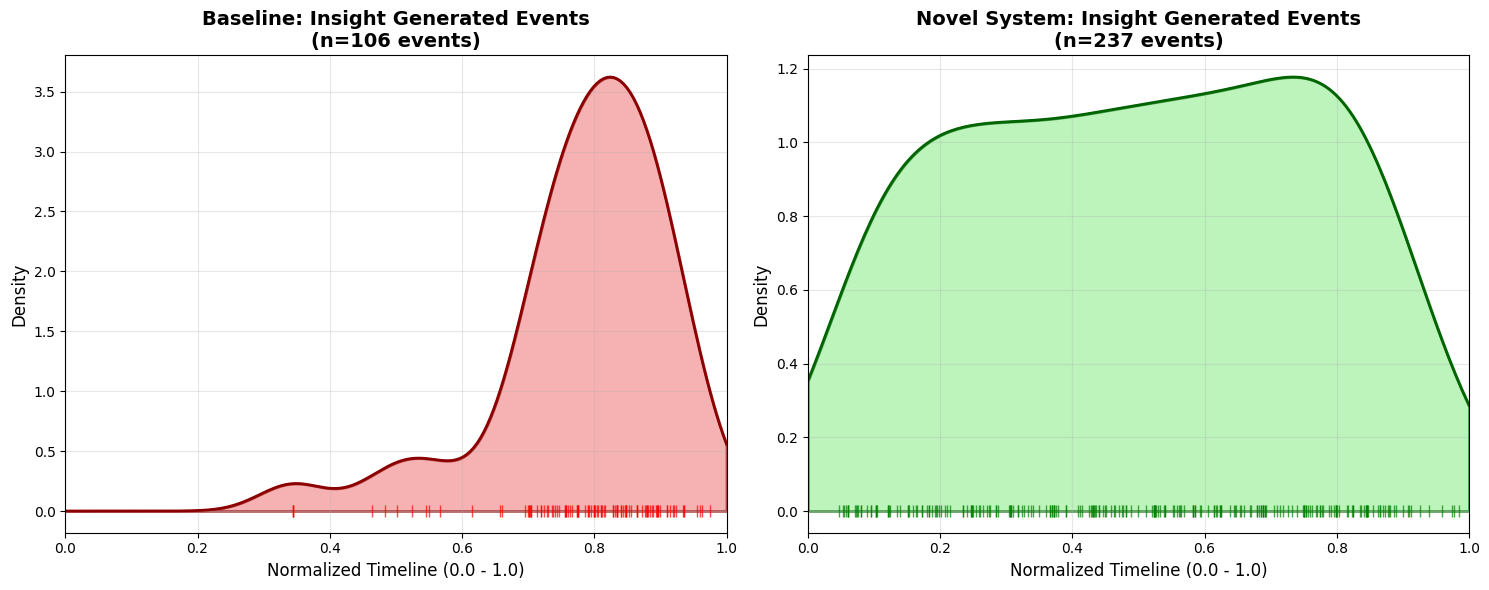


=== Summary Statistics ===
Baseline - Mean: 0.784, Std: 0.129, Median: 0.804
NS - Mean: 0.501, Std: 0.261, Median: 0.523


In [21]:
# Create continuous density plots for insight_generated events using KDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Baseline density plot
if insight_events['baseline'] and len(insight_events['baseline']) > 1:
    # Create KDE
    kde_baseline = gaussian_kde(insight_events['baseline'])
    x_baseline = np.linspace(0, 1, 200)
    density_baseline = kde_baseline(x_baseline)
    
    # Plot continuous density
    ax1.fill_between(x_baseline, density_baseline, alpha=0.6, color='lightcoral', 
                     edgecolor='darkred', linewidth=2)
    ax1.plot(x_baseline, density_baseline, color='darkred', linewidth=2)
    
    # Add rug plot for actual data points
    ax1.plot(insight_events['baseline'], np.zeros_like(insight_events['baseline']), 
             '|', color='red', markersize=8, alpha=0.7)
    
    ax1.set_title(f'Baseline: Insight Generated Events\n(n={len(insight_events["baseline"])} events)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
elif insight_events['baseline'] and len(insight_events['baseline']) == 1:
    # Single point - show as vertical line
    ax1.axvline(insight_events['baseline'][0], color='red', linewidth=3, alpha=0.8)
    ax1.set_title(f'Baseline: Insight Generated Events\n(n=1 event)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
else:
    ax1.text(0.5, 0.5, 'No insight_generated\nevents in baseline', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Baseline: Insight Generated Events', fontsize=14, fontweight='bold')

# NS density plot  
if insight_events['ns'] and len(insight_events['ns']) > 1:
    # Create KDE
    kde_ns = gaussian_kde(insight_events['ns'])
    x_ns = np.linspace(0, 1, 200)
    density_ns = kde_ns(x_ns)
    
    # Plot continuous density
    ax2.fill_between(x_ns, density_ns, alpha=0.6, color='lightgreen', 
                     edgecolor='darkgreen', linewidth=2)
    ax2.plot(x_ns, density_ns, color='darkgreen', linewidth=2)
    
    # Add rug plot for actual data points
    ax2.plot(insight_events['ns'], np.zeros_like(insight_events['ns']), 
             '|', color='green', markersize=8, alpha=0.7)
    
    ax2.set_title(f'Narrative Scaffolding: Insight Generated Events\n(n={len(insight_events["ns"])} events)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
elif insight_events['ns'] and len(insight_events['ns']) == 1:
    # Single point - show as vertical line
    ax2.axvline(insight_events['ns'][0], color='green', linewidth=3, alpha=0.8)
    ax2.set_title(f'Narrative Scaffolding: Insight Generated Events\n(n=1 event)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Normalized Timeline (0.0 - 1.0)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
else:
    ax2.text(0.5, 0.5, 'No insight_generated\nevents in NS', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Narrative Scaffolding: Insight Generated Events', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
if insight_events['baseline']:
    baseline_mean = np.mean(insight_events['baseline'])
    baseline_std = np.std(insight_events['baseline'])
    baseline_median = np.median(insight_events['baseline'])
    print(f"Baseline - Mean: {baseline_mean:.3f}, Std: {baseline_std:.3f}, Median: {baseline_median:.3f}")
else:
    print("Baseline - No insight_generated events")

if insight_events['ns']:
    ns_mean = np.mean(insight_events['ns'])
    ns_std = np.std(insight_events['ns'])
    ns_median = np.median(insight_events['ns'])
    print(f"NS - Mean: {ns_mean:.3f}, Std: {ns_std:.3f}, Median: {ns_median:.3f}")
else:
    print("NS - No insight_generated events")

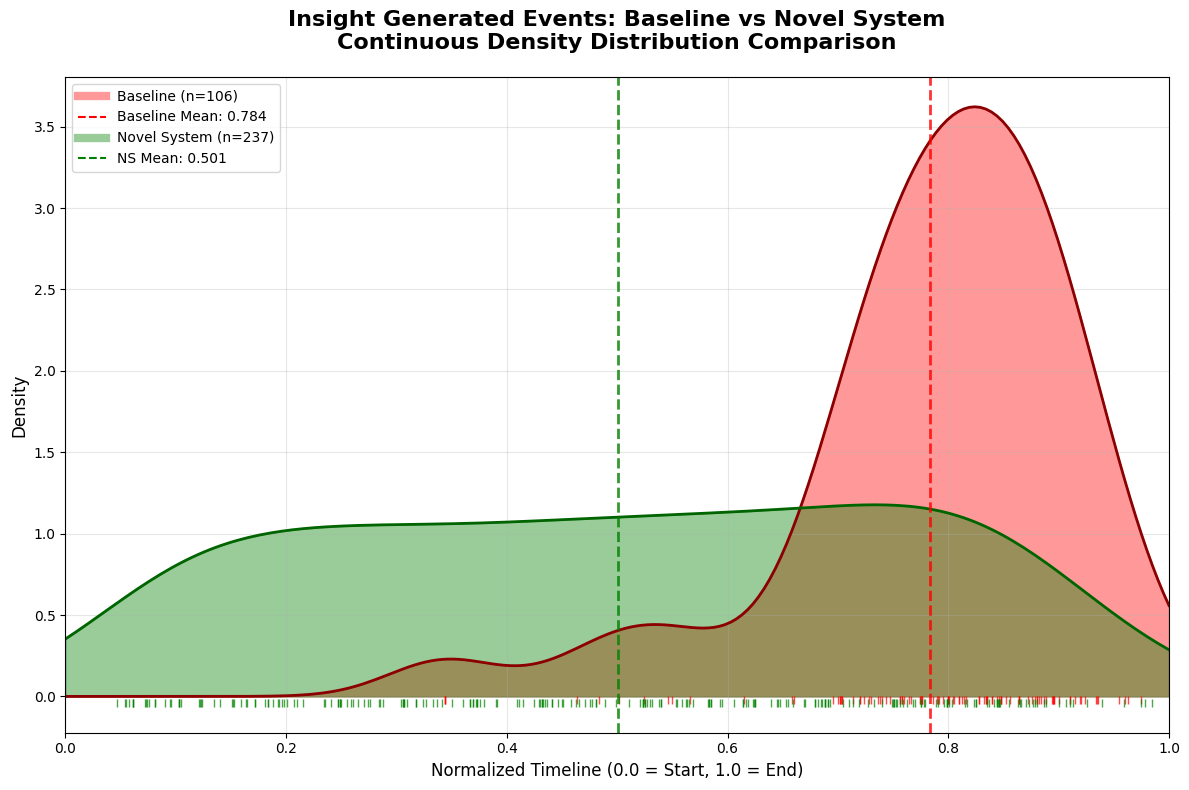


=== Statistical Comparison ===
Mann-Whitney U test: statistic=20574.500, p-value=0.0000
Kolmogorov-Smirnov test: statistic=0.603, p-value=0.0000
Effect size (Cohen's d): -1.374
Effect size interpretation: large
Statistical significance (α=0.05): significant


In [22]:
# Create combined continuous overlay density plot for comparison
plt.figure(figsize=(12, 8))

x_range = np.linspace(0, 1, 200)

# Plot baseline and NS with continuous KDE on the same axes
if insight_events['baseline'] and len(insight_events['baseline']) > 1:
    kde_baseline = gaussian_kde(insight_events['baseline'])
    density_baseline = kde_baseline(x_range)
    
    plt.fill_between(x_range, density_baseline, alpha=0.4, color='red', 
                     label=f'Baseline (n={len(insight_events["baseline"])})')
    plt.plot(x_range, density_baseline, color='darkred', linewidth=2)
    
    # Add rug plot
    plt.plot(insight_events['baseline'], 
             np.full_like(insight_events['baseline'], -0.02), 
             '|', color='red', markersize=6, alpha=0.7)

elif insight_events['baseline'] and len(insight_events['baseline']) == 1:
    plt.axvline(insight_events['baseline'][0], color='red', linewidth=3, alpha=0.8,
                label=f'Baseline (n=1)')

if insight_events['ns'] and len(insight_events['ns']) > 1:
    kde_ns = gaussian_kde(insight_events['ns'])
    density_ns = kde_ns(x_range)
    
    plt.fill_between(x_range, density_ns, alpha=0.4, color='green', 
                     label=f'Narrative Scaffolding (n={len(insight_events["ns"])})')
    plt.plot(x_range, density_ns, color='darkgreen', linewidth=2)
    
    # Add rug plot
    plt.plot(insight_events['ns'], 
             np.full_like(insight_events['ns'], -0.04), 
             '|', color='green', markersize=6, alpha=0.7)

elif insight_events['ns'] and len(insight_events['ns']) == 1:
    plt.axvline(insight_events['ns'][0], color='green', linewidth=3, alpha=0.8,
                label=f'Narrative Scaffolding (n=1)')

plt.title('Insight Generated Events: Baseline vs Narrative Scaffolding\nContinuous Density Distribution Comparison', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

# Add vertical lines for means if data exists
if insight_events['baseline']:
    baseline_mean = np.mean(insight_events['baseline'])
    plt.axvline(baseline_mean, color='red', linestyle='--', alpha=0.8, linewidth=2)

if insight_events['ns']:
    ns_mean = np.mean(insight_events['ns'])
    plt.axvline(ns_mean, color='green', linestyle='--', alpha=0.8, linewidth=2)

# Create custom legend
legend_elements = []
if insight_events['baseline']:
    baseline_mean = np.mean(insight_events['baseline'])
    legend_elements.extend([
        plt.Line2D([0], [0], color='red', alpha=0.4, linewidth=6, 
                   label=f'Baseline (n={len(insight_events["baseline"])})'),
        plt.Line2D([0], [0], color='red', linestyle='--', 
                   label=f'Baseline Mean: {baseline_mean:.3f}')
    ])

if insight_events['ns']:
    ns_mean = np.mean(insight_events['ns'])
    legend_elements.extend([
        plt.Line2D([0], [0], color='green', alpha=0.4, linewidth=6, 
                   label=f'Narrative Scaffolding (n={len(insight_events["ns"])})'),
        plt.Line2D([0], [0], color='green', linestyle='--', 
                   label=f'NS Mean: {ns_mean:.3f}')
    ])

if legend_elements:
    plt.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

# Statistical comparison if both conditions have data
if insight_events['baseline'] and insight_events['ns']:
    print("\n=== Statistical Comparison ===")
    
    # Mann-Whitney U test (non-parametric)
    statistic, p_value = stats.mannwhitneyu(insight_events['baseline'], insight_events['ns'])
    print(f"Mann-Whitney U test: statistic={statistic:.3f}, p-value={p_value:.4f}")
    
    # Kolmogorov-Smirnov test
    ks_stat, ks_p = stats.ks_2samp(insight_events['baseline'], insight_events['ns'])
    print(f"Kolmogorov-Smirnov test: statistic={ks_stat:.3f}, p-value={ks_p:.4f}")
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((np.std(insight_events['baseline'])**2 + np.std(insight_events['ns'])**2) / 2)
    cohen_d = (np.mean(insight_events['ns']) - np.mean(insight_events['baseline'])) / pooled_std
    print(f"Effect size (Cohen's d): {cohen_d:.3f}")
    
    if abs(cohen_d) < 0.2:
        effect_label = "negligible"
    elif abs(cohen_d) < 0.5:
        effect_label = "small"
    elif abs(cohen_d) < 0.8:
        effect_label = "medium" 
    else:
        effect_label = "large"
    
    print(f"Effect size interpretation: {effect_label}")
    
    significance = "significant" if p_value < 0.05 else "not significant"
    print(f"Statistical significance (α=0.05): {significance}")
else:
    print("\n=== Statistical Comparison ===")
    print("Cannot perform statistical comparison - one or both conditions have no insight_generated events")

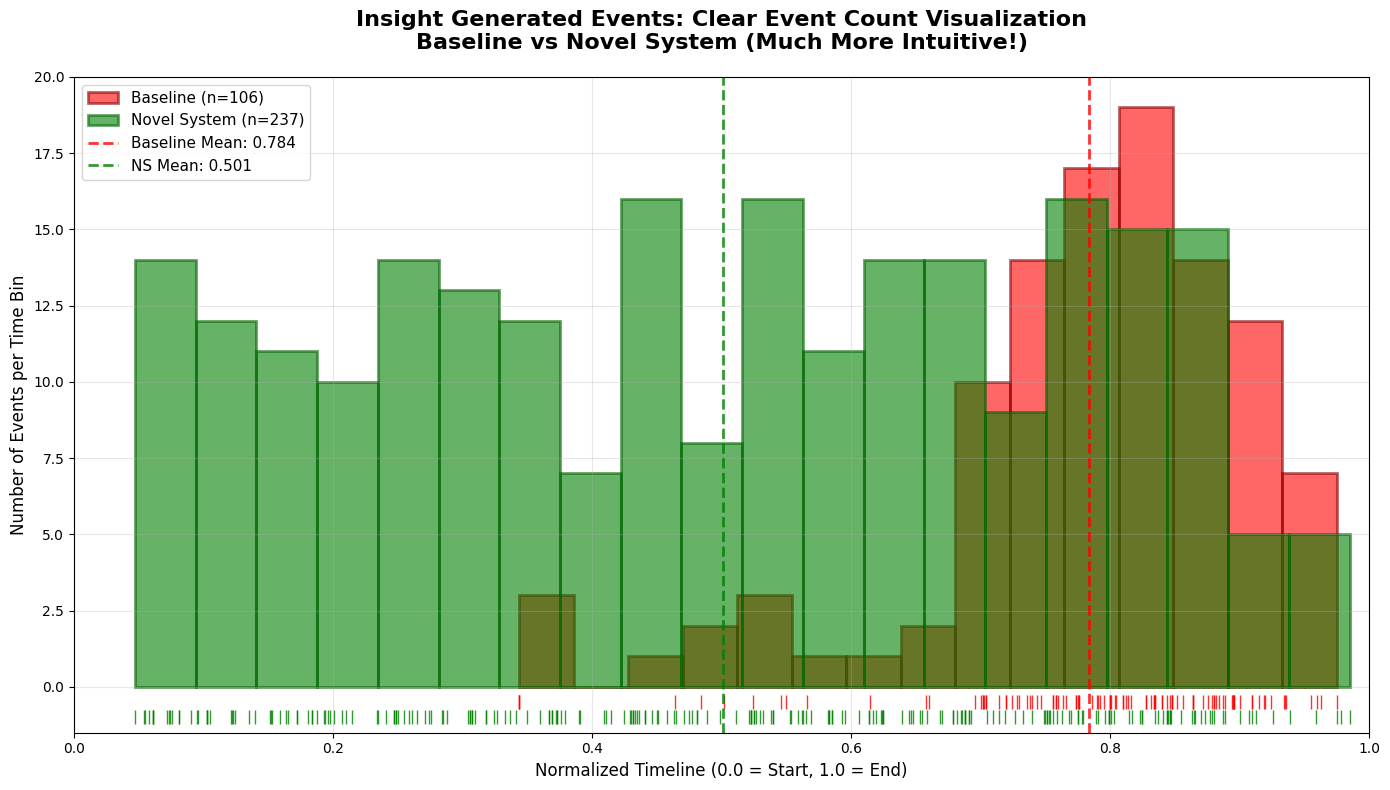

=== Clear Interpretation with Event Count Y-Axis ===
Peak activity (highest bins):
  Baseline: 19 insights in busiest time period
  NS: 16 insights in busiest time period
  NS has 0.8x more insights in peak periods

Total insight generation:
  Baseline: 106 insights across all participants
  NS: 237 insights across all participants
  Volume ratio: 2.2x more NS insights

What this means:
  • NS participants generate 2.2x more insights
  • Peak periods show 0.8x higher insight activity with NS
  • The height differences directly show insight generation volume differences
  • No confusing 'density' math - just straightforward insight counts!

✅ RECOMMENDATION: Use 'Number of Events' for y-axis instead of 'Density'
   Everyone understands event counts, but density is mathematically abstract.


In [23]:
# Create the BEST visualization using Event Count (most intuitive)
plt.figure(figsize=(14, 8))

# Use event count instead of density - much clearer!
if insight_events['baseline']:
    counts_b, bins_b, patches_b = plt.hist(insight_events['baseline'], bins=15, 
                                          alpha=0.6, color='red', edgecolor='darkred', 
                                          linewidth=2, label=f'Baseline (n={len(insight_events["baseline"])})')
    
    # Add individual event markers
    plt.plot(insight_events['baseline'], 
             np.full_like(insight_events['baseline'], -0.5), 
             '|', color='red', markersize=10, alpha=0.8)

if insight_events['ns']:
    counts_ns, bins_ns, patches_ns = plt.hist(insight_events['ns'], bins=20, 
                                             alpha=0.6, color='green', edgecolor='darkgreen', 
                                             linewidth=2, label=f'Narrative Scaffolding (n={len(insight_events["ns"])})')
    
    # Add individual event markers
    plt.plot(insight_events['ns'], 
             np.full_like(insight_events['ns'], -1), 
             '|', color='green', markersize=10, alpha=0.8)

# Add mean lines
if insight_events['baseline']:
    baseline_mean = np.mean(insight_events['baseline'])
    plt.axvline(baseline_mean, color='red', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Baseline Mean: {baseline_mean:.3f}')

if insight_events['ns']:
    ns_mean = np.mean(insight_events['ns'])
    plt.axvline(ns_mean, color='green', linestyle='--', linewidth=2, alpha=0.8,
                label=f'NS Mean: {ns_mean:.3f}')

plt.title('Insight Generated Events: Clear Event Count Visualization\nBaseline vs Narrative Scaffolding (Much More Intuitive!)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Normalized Timeline (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Number of Events per Time Bin', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(bottom=-1.5)

plt.tight_layout()
plt.show()

# Show clear interpretation
print("=== Clear Interpretation with Event Count Y-Axis ===")
if insight_events['baseline'] and insight_events['ns']:
    max_baseline = max(counts_b) if 'counts_b' in locals() and len(counts_b) > 0 else 0
    max_ns = max(counts_ns) if 'counts_ns' in locals() and len(counts_ns) > 0 else 0
    
    print(f"Peak activity (highest bins):")
    print(f"  Baseline: {max_baseline:.0f} insights in busiest time period")
    print(f"  NS: {max_ns:.0f} insights in busiest time period")
    
    if max_baseline > 0:
        print(f"  NS has {max_ns/max_baseline:.1f}x more insights in peak periods")
    
    total_baseline = len(insight_events['baseline'])
    total_ns = len(insight_events['ns'])
    
    print(f"\nTotal insight generation:")
    print(f"  Baseline: {total_baseline} insights across all participants")
    print(f"  NS: {total_ns} insights across all participants")
    print(f"  Volume ratio: {total_ns/total_baseline:.1f}x more NS insights")
    
    print(f"\nWhat this means:")
    print(f"  • NS participants generate {total_ns/total_baseline:.1f}x more insights")
    print(f"  • Peak periods show {max_ns/max_baseline:.1f}x higher insight activity with NS")
    print(f"  • The height differences directly show insight generation volume differences")
    print(f"  • No confusing 'density' math - just straightforward insight counts!")

print(f"\n✅ RECOMMENDATION: Use 'Number of Events' for y-axis instead of 'Density'")
print(f"   Everyone understands event counts, but density is mathematically abstract.")

## Per-Participant Insight Analysis

Analyzing insight generation patterns for individual participants to understand the distribution and timing of insights across different participants in each condition.

In [24]:
# Calculate per-participant insight statistics
def calculate_per_participant_insights():
    """
    Calculate insight generation statistics for each participant
    """
    
    baseline_participants = {}
    ns_participants = {}
    
    event_folder = 'participant_events'
    
    # Process baseline files - get insights per participant
    baseline_files = glob.glob(f'{event_folder}/*_baseline.csv')
    for file_path in baseline_files:
        try:
            participant_id = os.path.basename(file_path).replace('_baseline.csv', '')
            events_df = pd.read_csv(file_path)
            insight_events = events_df[events_df['event_type'] == 'insight_generated']
            
            if not insight_events.empty:
                timestamps = insight_events['timestamp_normalized'].tolist()
                baseline_participants[participant_id] = {
                    'count': len(timestamps),
                    'timestamps': timestamps,
                    'mean_time': np.mean(timestamps),
                    'first_insight': min(timestamps),
                    'last_insight': max(timestamps)
                }
            else:
                baseline_participants[participant_id] = {
                    'count': 0,
                    'timestamps': [],
                    'mean_time': None,
                    'first_insight': None,
                    'last_insight': None
                }
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    # Process NS files - get insights per participant
    ns_files = glob.glob(f'{event_folder}/*_ns.csv')
    for file_path in ns_files:
        try:
            participant_id = os.path.basename(file_path).replace('_ns.csv', '')
            events_df = pd.read_csv(file_path)
            insight_events = events_df[events_df['event_type'] == 'insight_generated']
            
            if not insight_events.empty:
                timestamps = insight_events['timestamp_normalized'].tolist()
                ns_participants[participant_id] = {
                    'count': len(timestamps),
                    'timestamps': timestamps,
                    'mean_time': np.mean(timestamps),
                    'first_insight': min(timestamps),
                    'last_insight': max(timestamps)
                }
            else:
                ns_participants[participant_id] = {
                    'count': 0,
                    'timestamps': [],
                    'mean_time': None,
                    'first_insight': None,
                    'last_insight': None
                }
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    return baseline_participants, ns_participants

# Get per-participant data
baseline_participants, ns_participants = calculate_per_participant_insights()

# Calculate summary statistics
baseline_counts = [data['count'] for data in baseline_participants.values()]
ns_counts = [data['count'] for data in ns_participants.values()]

baseline_mean_times = [data['mean_time'] for data in baseline_participants.values() if data['mean_time'] is not None]
ns_mean_times = [data['mean_time'] for data in ns_participants.values() if data['mean_time'] is not None]

print("=== Per-Participant Insight Statistics ===")
print(f"Baseline participants: {len(baseline_participants)}")
print(f"NS participants: {len(ns_participants)}")
print(f"Baseline insights per participant: mean={np.mean(baseline_counts):.2f}, std={np.std(baseline_counts):.2f}")
print(f"NS insights per participant: mean={np.mean(ns_counts):.2f}, std={np.std(ns_counts):.2f}")
print(f"Individual participant range - Baseline: {min(baseline_counts)}-{max(baseline_counts)}")
print(f"Individual participant range - NS: {min(ns_counts)}-{max(ns_counts)}")

if baseline_mean_times and ns_mean_times:
    print(f"Average timing of insights:")
    print(f"  Baseline mean insight time: {np.mean(baseline_mean_times):.3f}")
    print(f"  NS mean insight time: {np.mean(ns_mean_times):.3f}")

# Statistical test on insight counts per participant
if baseline_counts and ns_counts:
    t_stat, p_val = stats.ttest_ind(ns_counts, baseline_counts)
    print(f"\nt-test on insights per participant: t={t_stat:.3f}, p={p_val:.4f}")
    
    effect_size = (np.mean(ns_counts) - np.mean(baseline_counts)) / np.sqrt((np.std(ns_counts)**2 + np.std(baseline_counts)**2) / 2)
    print(f"Effect size (Cohen's d): {effect_size:.3f}")
    
    print(f"\nAverage participant profile:")
    print(f"Baseline: ~{np.mean(baseline_counts):.1f} insights per participant")
    print(f"NS: ~{np.mean(ns_counts):.1f} insights per participant")
    print(f"Ratio: NS participants generate {np.mean(ns_counts)/np.mean(baseline_counts):.1f}x more insights on average")

=== Per-Participant Insight Statistics ===
Baseline participants: 17
NS participants: 17
Baseline insights per participant: mean=6.24, std=1.55
NS insights per participant: mean=13.94, std=4.84
Individual participant range - Baseline: 4-10
Individual participant range - NS: 9-27
Average timing of insights:
  Baseline mean insight time: 0.784
  NS mean insight time: 0.501

t-test on insights per participant: t=6.059, p=0.0000
Effect size (Cohen's d): 2.142

Average participant profile:
Baseline: ~6.2 insights per participant
NS: ~13.9 insights per participant
Ratio: NS participants generate 2.2x more insights on average
